# Домашнее задание 2. Микросервисная архитектура
Студент: __Соловьев Егор Николаевич__, М08-501НД, 05.04.2026

Это задание выполняется в рамках модуля 2 «Микросервисная архитектура». Вы закрепите навыки разделения монолита на микросервисы.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [ ]:
%load_ext ipyform  # работа с формами в GoogleColab
%form_config --auto-detect 1
# Это для себя заметка

The ipyform extension is already loaded. To reload it, use:
  %reload_ext ipyform


In [13]:
# Это для себя заметка
# @title Настройки модели { display-mode: "form" }

learning_rate = 0.01  # @param {type:"number"}
epochs = 10           # @param {type:"integer", min:1, max:100}
optimizer = "adam"    # @param ["adam", "sgd", "rmsprop"]

Error at line 5. Inputs only support the following properties: ['type', 'placeholder']. Found: min


FormWidget(children=(VBox(children=(HTML(value='<button onClick="code_toggle(\'addec5248\')" id="addec5248">Hi…

In [ ]:
%%capture
!sudo apt install graphviz
!pip install docker-compose-diagram
!pip install fastapi uvicorn[standard] -qq
!pip install --upgrade sqlalchemy

### Задание 1. Сравнить монолитную и микросервисную архитектуру: преимущества и недостатки

В каком случае вы не будете разбивать монолит на микросервисы и почему?

В каком случае монолит обязательно разбивать на микросервисы и почему?

Error at line 4. Inputs only support the following properties: ['type', 'placeholder']. Found: min


FormWidget(children=(VBox(children=(HTML(value='<button onClick="code_toggle(\'a9762ee40\')" id="a9762ee40">Hi…

### Задание 2. Разбить монолит на микросервисы

Есть монолитное веб-приложение. Четыре отдела генерируют нагрузку по 100 RPS каждый (суммарно ≈400 RPS), а текущая пропускная способность веб-сервера — ≈200 RPS; начинает ощущаться деградация. Для упрощения считаем, что сеть не узкое место, ресурсов RAM/CPU/HDD достаточно, техдолг низкий, финансовых ограничений нет.

Задача. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита:
- Как вы диагностируете связность и выбираете границы сервисов (по доменам, бизнес-процессам или данным, допустим комбинированный вариант).
- Какие части вы вынесете первыми, чтобы снять узкое место по RPS, и почему.
- Как будете обеспечивать временную совместную работу старого и нового (этапный переход, strangler pattern).
- Кто владеет данными после разделения и как вы минимизируете риски согласованности.
- Нужен ли API-Gateway на входе и какие задачи он возьмет (маршрутизация, аутентификация, агрегация).



In [ ]:
%%writefile /content/diagram.py
from diagrams import Cluster, Diagram
from diagrams.onprem.compute import Server
from diagrams.aws.database import RDS
from diagrams.programming.flowchart import Action
from diagrams.onprem.client import Users

with Diagram("monolith", show=False):

    with Cluster("Отделы"):
        depts = [Users("логистика"),
                     Users("закупки"),
                     Users("контроль качества"),
                     Users("бухгалтерия")]

    with Cluster("Монолит, среда развертывания - bare metal"):
      with Cluster("Данные"):
        storage = [RDS("единая база данных")]

      with Cluster("Веб-сервер"):
        webserver = [Server("сервер")]

      with Cluster("Протоколы"):
        protocols = [Action("HTTPS"),
        Action("RPC"),
        Action("HTTP")]

      with Cluster("Формат"):
        formats = [Action("XML"),
        Action("JSON"),
        Action("Текст")]

      with Cluster("Бизнес-процесс"):
        process = [Action("Оплатить перевозку"),
        Action("Оплатить товар"),
        Action("Оплатить инспекцию")]

    storage[0] >> webserver[0]
    webserver[0] >> storage[0]
    storage[0] >> depts[3]
    depts[3] >> storage[0]

    depts[0] >> process[0] >> formats[0] >> protocols[0] >> webserver[0]
    depts[1] >> process[1] >> formats[1] >> protocols[1] >> webserver[0]
    depts[2] >> process[2] >> formats[2] >> protocols[2] >> webserver[0]


Overwriting /content/diagram.py


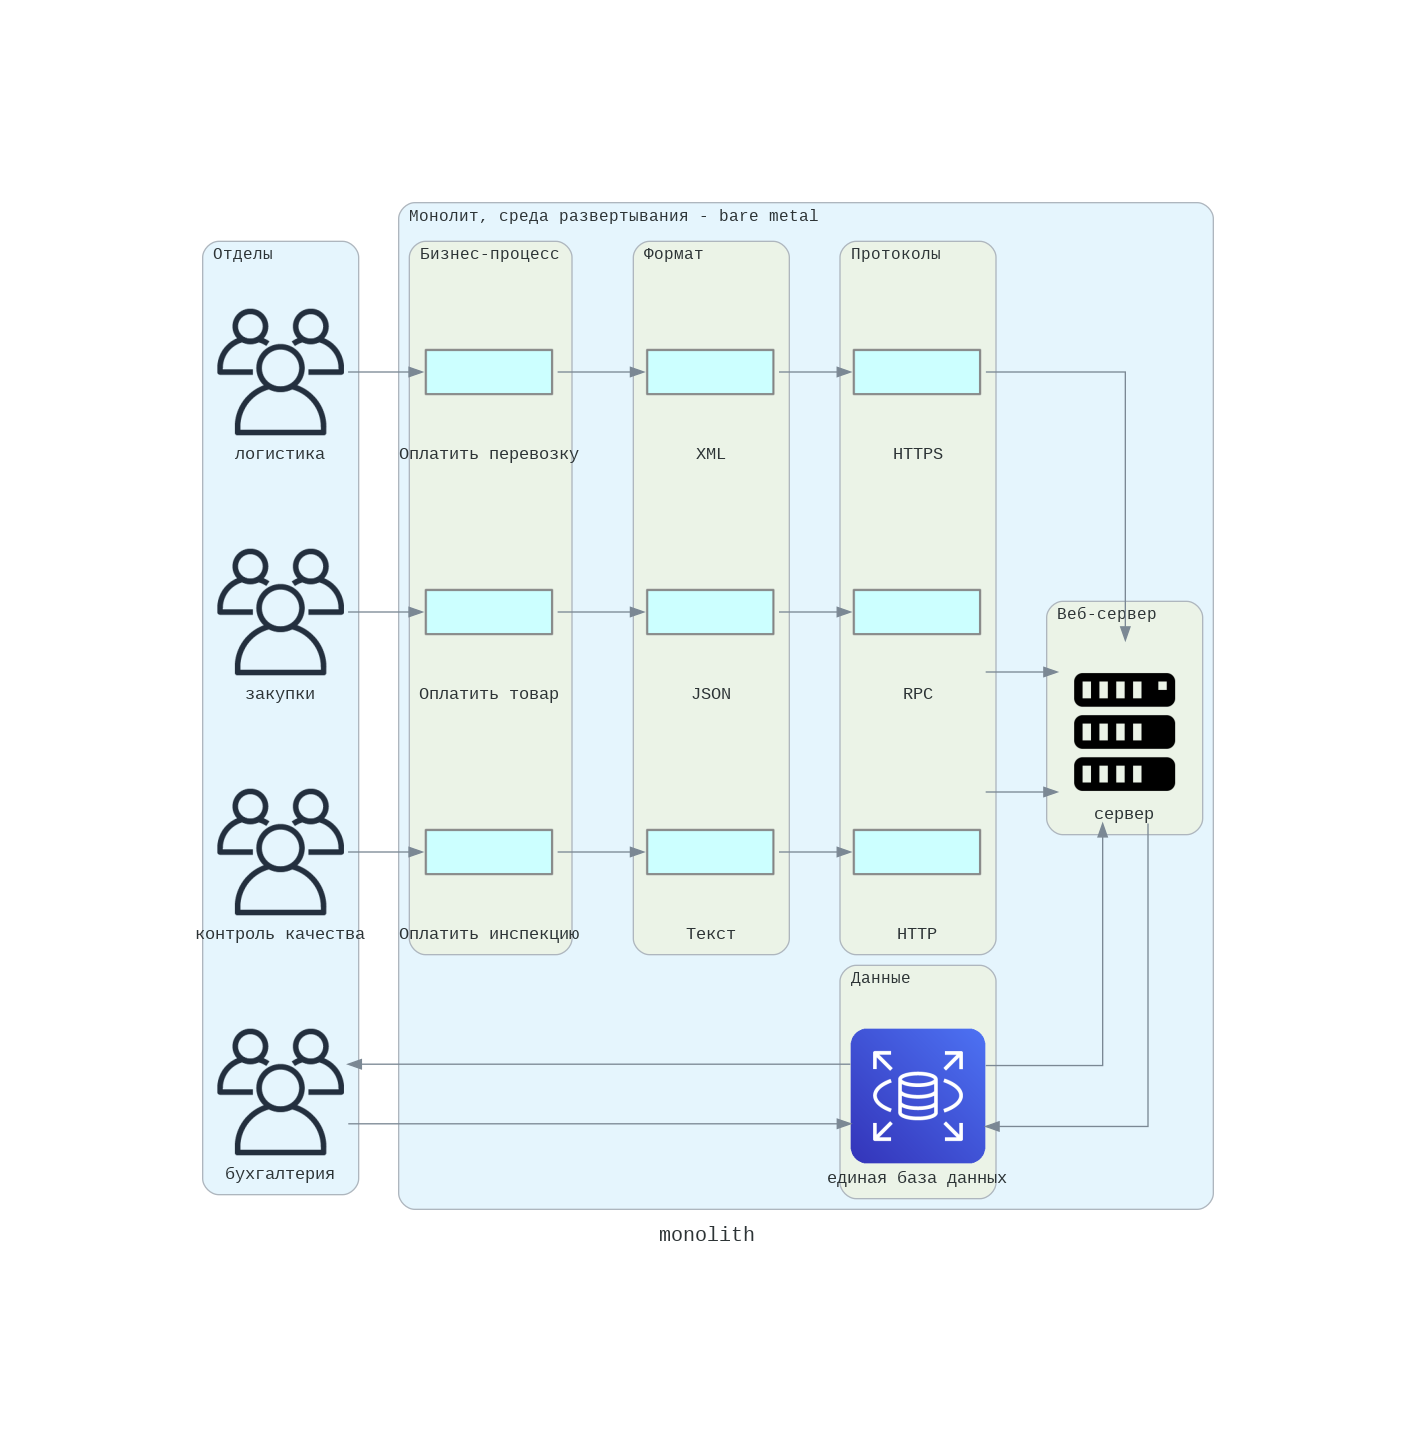

In [ ]:
from IPython.display import Image, display
!python diagram.py
image_path = '/content/monolith.png'
display(Image(filename=image_path))

### Задание 3. Составить документацию взаимодействия сервисов, используя библиотеку docker-compose-diagram

Изучите нотацию библиотеки [Diagrams](https://diagrams.mingrammer.com/docs/nodes/onprem) для указания изображений узлов.

Изучите библиотеку [docker-compose-diagram](https://github.com/skonik/docker-compose-diagram) для документирования докер-компоуз-файлов с помощью лейблов.

Создайте диаграмму простого взаимодействия сервисов (веб-сервер и база данных) добавляя лейблы, чтобы получилось примерно как изображено на рисунке.

%%html

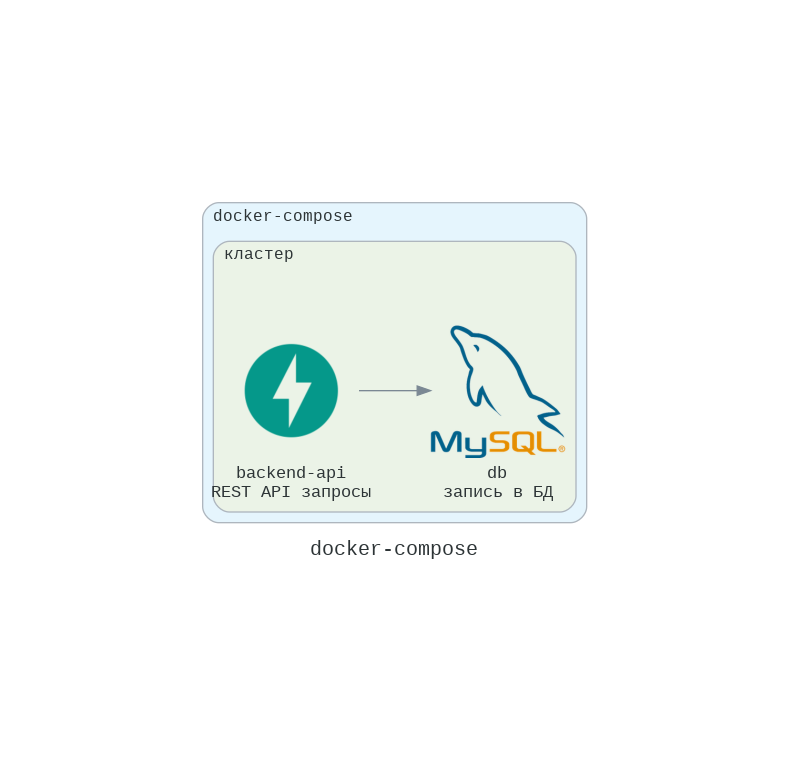

In [ ]:
%%writefile docker-compose.yml
services:

  backend-api:
    build:
      context: ..
      dockerfile: docker/django/Dockerfile
    image: dev_backend
    container_name: dev_backend
    restart: always
    volumes:
      - ..:/app/
    depends_on:
      - db
    working_dir: "/app/backend"
    expose:
      - 8000
    ports:
      - "8000:8000"
    command: runserver
    labels:
      "docker_compose_diagram.icon": "" # выберите diagrams.onprem.compute.Server или diagrams.programming.framework.Django
                                        #diagrams.programming.framework.Fastapi
                                        #diagrams.programming.framework.FastAPI
                                        #diagrams.programming.framework.Flask
      "docker_compose_diagram.cluster": "название"
      "docker_compose_diagram.description": "описание"



  db:
    container_name: backend_api_db
    image: mysql/mysql-server:8
    volumes:
      - mysql_data:/var/lib/mysql
    restart: unless-stopped
    ports:
      - "3306:3306"
    labels:
      "docker_compose_diagram.icon": "" #вставьте diagrams.onprem.database.Mysql, либо diagrams.onprem.database.MySQL
      "docker_compose_diagram.cluster": "название"
      "docker_compose_diagram.description": "описание"

Overwriting docker-compose.yml


In [ ]:
!compose-diagram --file docker-compose.yml --direction=LR --nodesep=1.2

File docker-compose.yml has been found. Reading! 📗 
Service: backend-api
   Service: {'docker_compose_diagram.icon': '', 
'docker_compose_diagram.cluster': '', 'docker_compose_diagram.description': ''}
Service: db
   Service: {'docker_compose_diagram.icon': '', 
'docker_compose_diagram.cluster': '', 'docker_compose_diagram.description': ''}
Your diagram has been saved in docker-compose.png 🖼️
⠹ Working..


In [ ]:
image_path = '/content/docker-compose.png'
display(Image(filename=image_path))

### Задание 4. Выбрать подходящие паттерны интеграции сервисов (REST/gRPC/брокеры)

Есть монолитное веб-приложение с пропускной способностью ≈200 RPS, при росте нагрузки до ≈400 RPS начинает ощущаться деградация.

Предложите 3 гипотезы, основываясь на [HDD-подходе](https://colab.research.google.com/drive/1vzl2jhLMJuLN-ZcYiPiIeJ7ribHMGDwt?usp=sharing) и исходя из вводных данных:

## REST (будет выдавать 1000 RPS)
* DevCost = 120000 — зарплата разработчиков.
* InfraCost =  50000 — стоимость инфраструктуры.
* featureEstimate = 85 — оценка фичи в стори-поинтах.
* ReworkRate =  0.2; процент доработок/исправлений — от 0.0 до 1.0.

## gRPC (будет выдавать 10000 RPS)

* DevCost = 1000000 — зарплата разработчиков.
* InfraCost =  500000 — стоимость инфраструктуры.
* featureEstimate = 850 — оценка фичи в стори-поинтах.
* ReworkRate =  0.4; процент доработок/исправлений — от 0.0 до 1.0.

## брокеры (будет выдавать 1000000 RPS)

* DevCost = 1200000 — зарплата разработчиков.
* InfraCost =  1500000 — стоимость инфраструктуры.
* featureEstimate = 8500 — оценка фичи в стори-поинтах.
* ReworkRate =  0.6; процент доработок/исправлений — от 0.0 до 1.0.

### Задание 5. Разработать схему ML-системы для обработки табличных данных

**Писать код не нужно.**

Нужно составить список вопросов, без которых невозможно начать разработку ML-системы, выбрать архитектуру и составить схематическое описание  ML-системы с помощью библиотеки Diagrams.

**Вводные данные от бизнеса: «Как привлечь клиентов на депозит?» и результат прошлой маркетинговой кампании.**

In [ ]:
!pip install scikit-learn -qqq
from sklearn.datasets import fetch_openml
X, y = fetch_openml("bank-marketing", version=1, as_frame=True, return_X_y=True)
display(X.merge(y,left_index=True,right_index=True).tail())
y.value_counts() #<-внес ли клиент срочный депозит по итогам маркетинговой компании? ("да = 2"/"нет = 1")

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,2
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,2
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,2
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,1
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,1


,count
Class,
1,39922
2,5289


In [ ]:
#Писать код не нужно !

## Итоговое оформление

1. Сформулируйте ниже 5–8 выводов, когда стоит разбивать монолит на микросервисы.
2. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита.
3. Запустите блокнот, чтобы получить диаграмму простого взаимодействия сервисов (веб-сервер и база данных), используя лейблы.
4. Обоснуйте в 5–8 предложениях выбранный паттерн интеграции сервисов.
5. Без чего немыслимо начинать разработку ML-системы?
6. Проверьте, что ноутбук запускается.  